# Robust Local Mean Decomposition (RLMD)

> Liu Z., Jin Y., Zuo M.J., Feng Z.  
> *Time-frequency representation based on robust local mean decomposition for multi-component AM-FM signal analysis.*  
> Mechanical Systems and Signal Processing, 95:468–487, 2017.

MATLAB reference: [`lmd_public.m`](https://www.mathworks.com/matlabcentral/fileexchange/66935-robust-local-mean-decomposition-rlmd) / `repo/RLMD/`.

## Motivation

Classical **LMD** (Smith, 2005) separates AM–FM mixtures into Product Functions
$\mathrm{PF}_i(t)=a_i(t)\,s_i(t)$, but is sensitive to **boundary effects**,
**moving-average span**, and the **sifting stop** rule.

**RLMD** keeps the LMD structure and adds three robustness strategies:

1. **Mirror extension** of extrema near the ends (`extd_r`)
2. **Data-driven MA span** (Liu’s histogram rule: mean $+3\sigma$ of extrema steps)
3. **Liu sifting stop**: minimise $f_j=\mathrm{RMS}(a_j-1)+|\mathrm{Kurt}(a_j-1)-3|$,
   then pick the locally optimal iteration


## 1. Imports


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import RLMD
from pysdkit.plot import plot_IMFs

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11
print(RLMD())

Robust Local Mean Decomposition (RLMD)


## 2. MATLAB `lmd_demo.m` signal

Original demo uses $f_s=10\,$kHz and $N=30000$. Here we use a lighter grid
($f_s=1000$, $N=3000$) with the **same formulas**:

$$
\begin{aligned}
x_1(t)&=\bigl(2+\cos(2\pi\cdot 0.5\,t)\bigr)\,
\cos\bigl(2\pi\cdot 5\,t+15\,t^2\bigr),\\
x_2(t)&=\cos(2\pi\cdot 2\,t),\\
x(t)&=x_1(t)+x_2(t).
\end{aligned}
$$


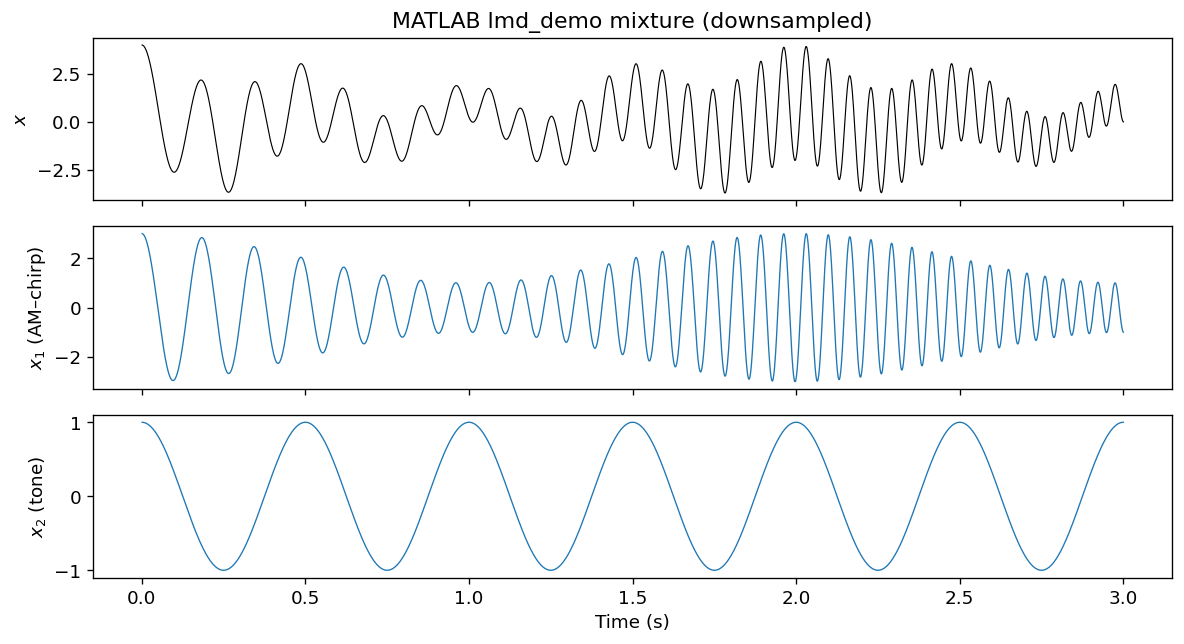

In [2]:
fs = 1000.0
N = 3000
t = np.arange(1, N + 1, dtype=float) / fs

x1 = (2.0 + np.cos(2 * np.pi * 0.5 * t)) * np.cos(2 * np.pi * 5 * t + 15 * t**2)
x2 = np.cos(2 * np.pi * 2 * t)
x = x1 + x2

fig, axes = plt.subplots(3, 1, figsize=(10, 5.5), sharex=True)
axes[0].plot(t, x, "k", lw=0.7)
axes[0].set_ylabel("$x$")
axes[0].set_title("MATLAB lmd_demo mixture (downsampled)")
axes[1].plot(t, x1, lw=0.8)
axes[1].set_ylabel("$x_1$ (AM–chirp)")
axes[2].plot(t, x2, lw=0.8)
axes[2].set_ylabel("$x_2$ (tone)")
axes[2].set_xlabel("Time (s)")
fig.tight_layout()
plt.show()

## 3. Run RLMD (MATLAB options)

```matlab
options.max_iter = 30;
options.max_pfs = 10;
[pf, ams, fms, ort] = lmd_public(x, options);
```


In [3]:
rlmd = RLMD(max_imfs=10, max_iter=30)
pfs, ams, fms = rlmd.fit_transform(x, return_all=True)

print("PFs + residue:", pfs.shape)
print("AMs:", ams.shape, "  FMs:", fms.shape)
print("reconstruction ‖x−ΣPF‖ =", np.linalg.norm(x - pfs.sum(0)))

for name, true in [("x1", x1), ("x2", x2)]:
    best = 0.0
    best_k = -1
    for k in range(pfs.shape[0] - 1):
        c = abs(float(np.corrcoef(true, pfs[k])[0, 1]))
        if c > best:
            best, best_k = c, k
    print(f"  {name} ↔ PF{best_k+1}: |corr|={best:.4f}")

PFs + residue: (3, 3000)
AMs: (2, 3000)   FMs: (2, 3000)
reconstruction ‖x−ΣPF‖ = 4.326142984700647e-15
  x1 ↔ PF1: |corr|=0.9997
  x2 ↔ PF2: |corr|=0.9984


### 3.1 Product functions


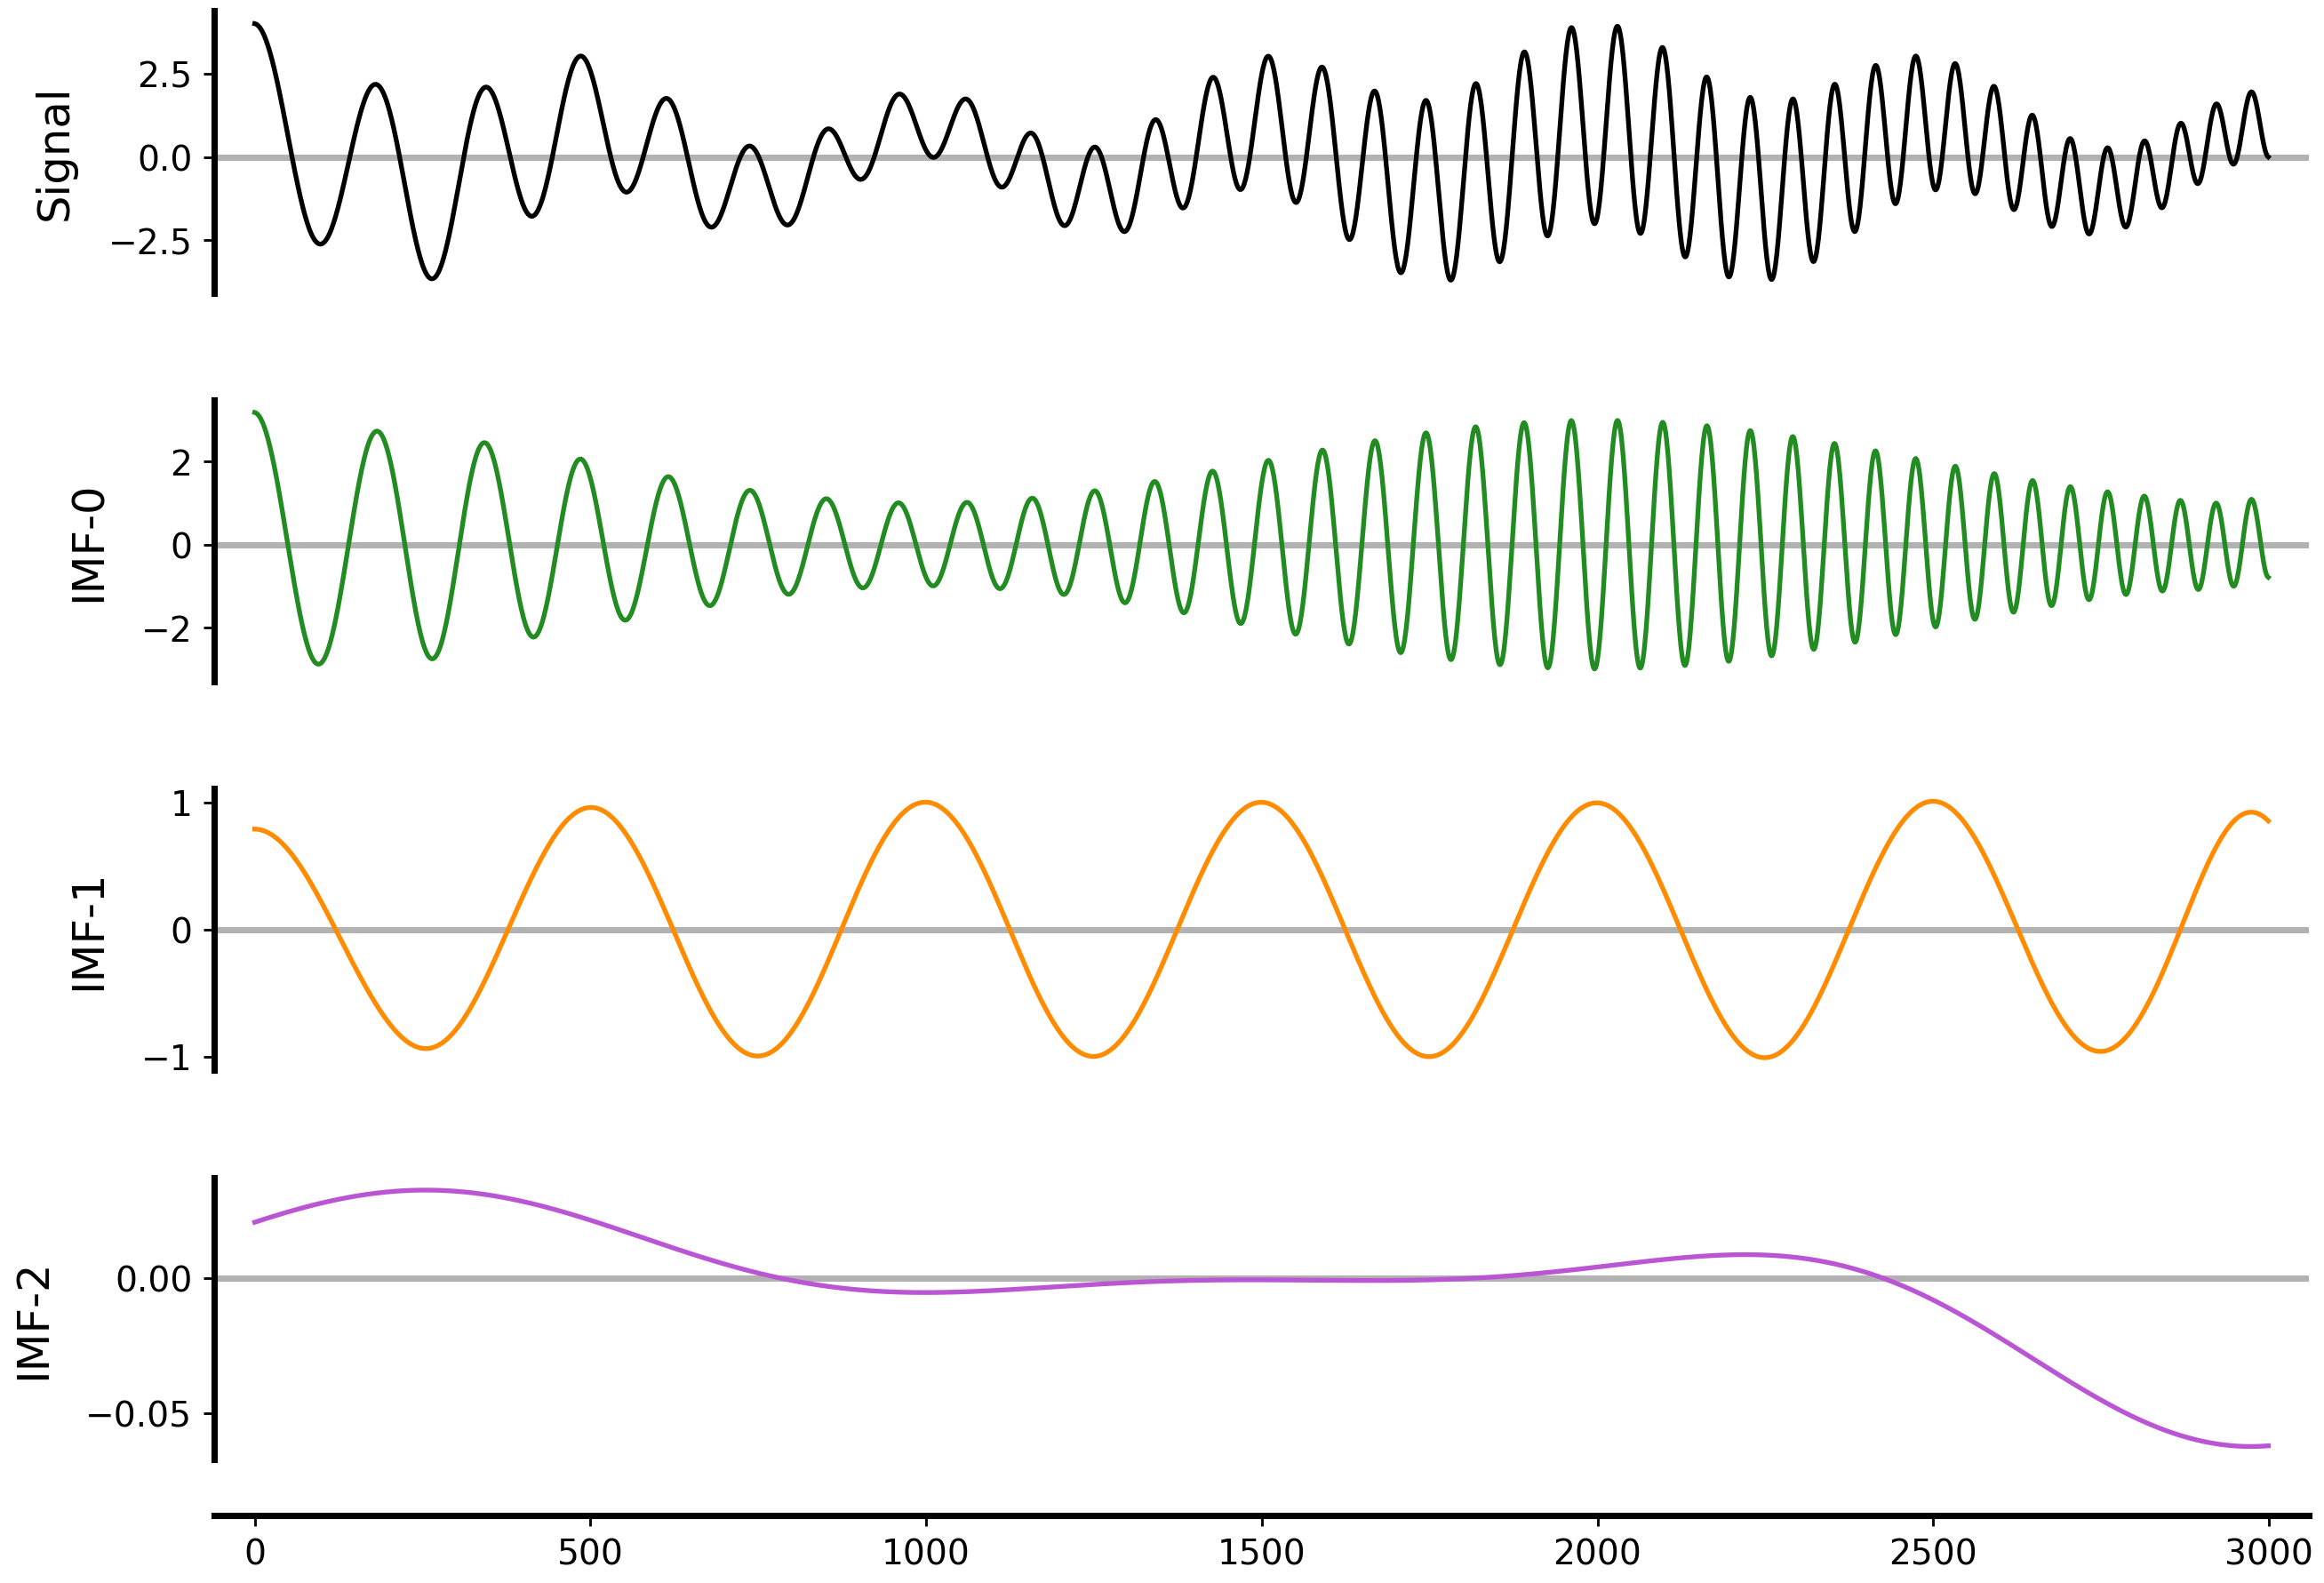

In [4]:
_ = plot_IMFs(x, pfs)

### 3.2 Estimated modes vs ground truth


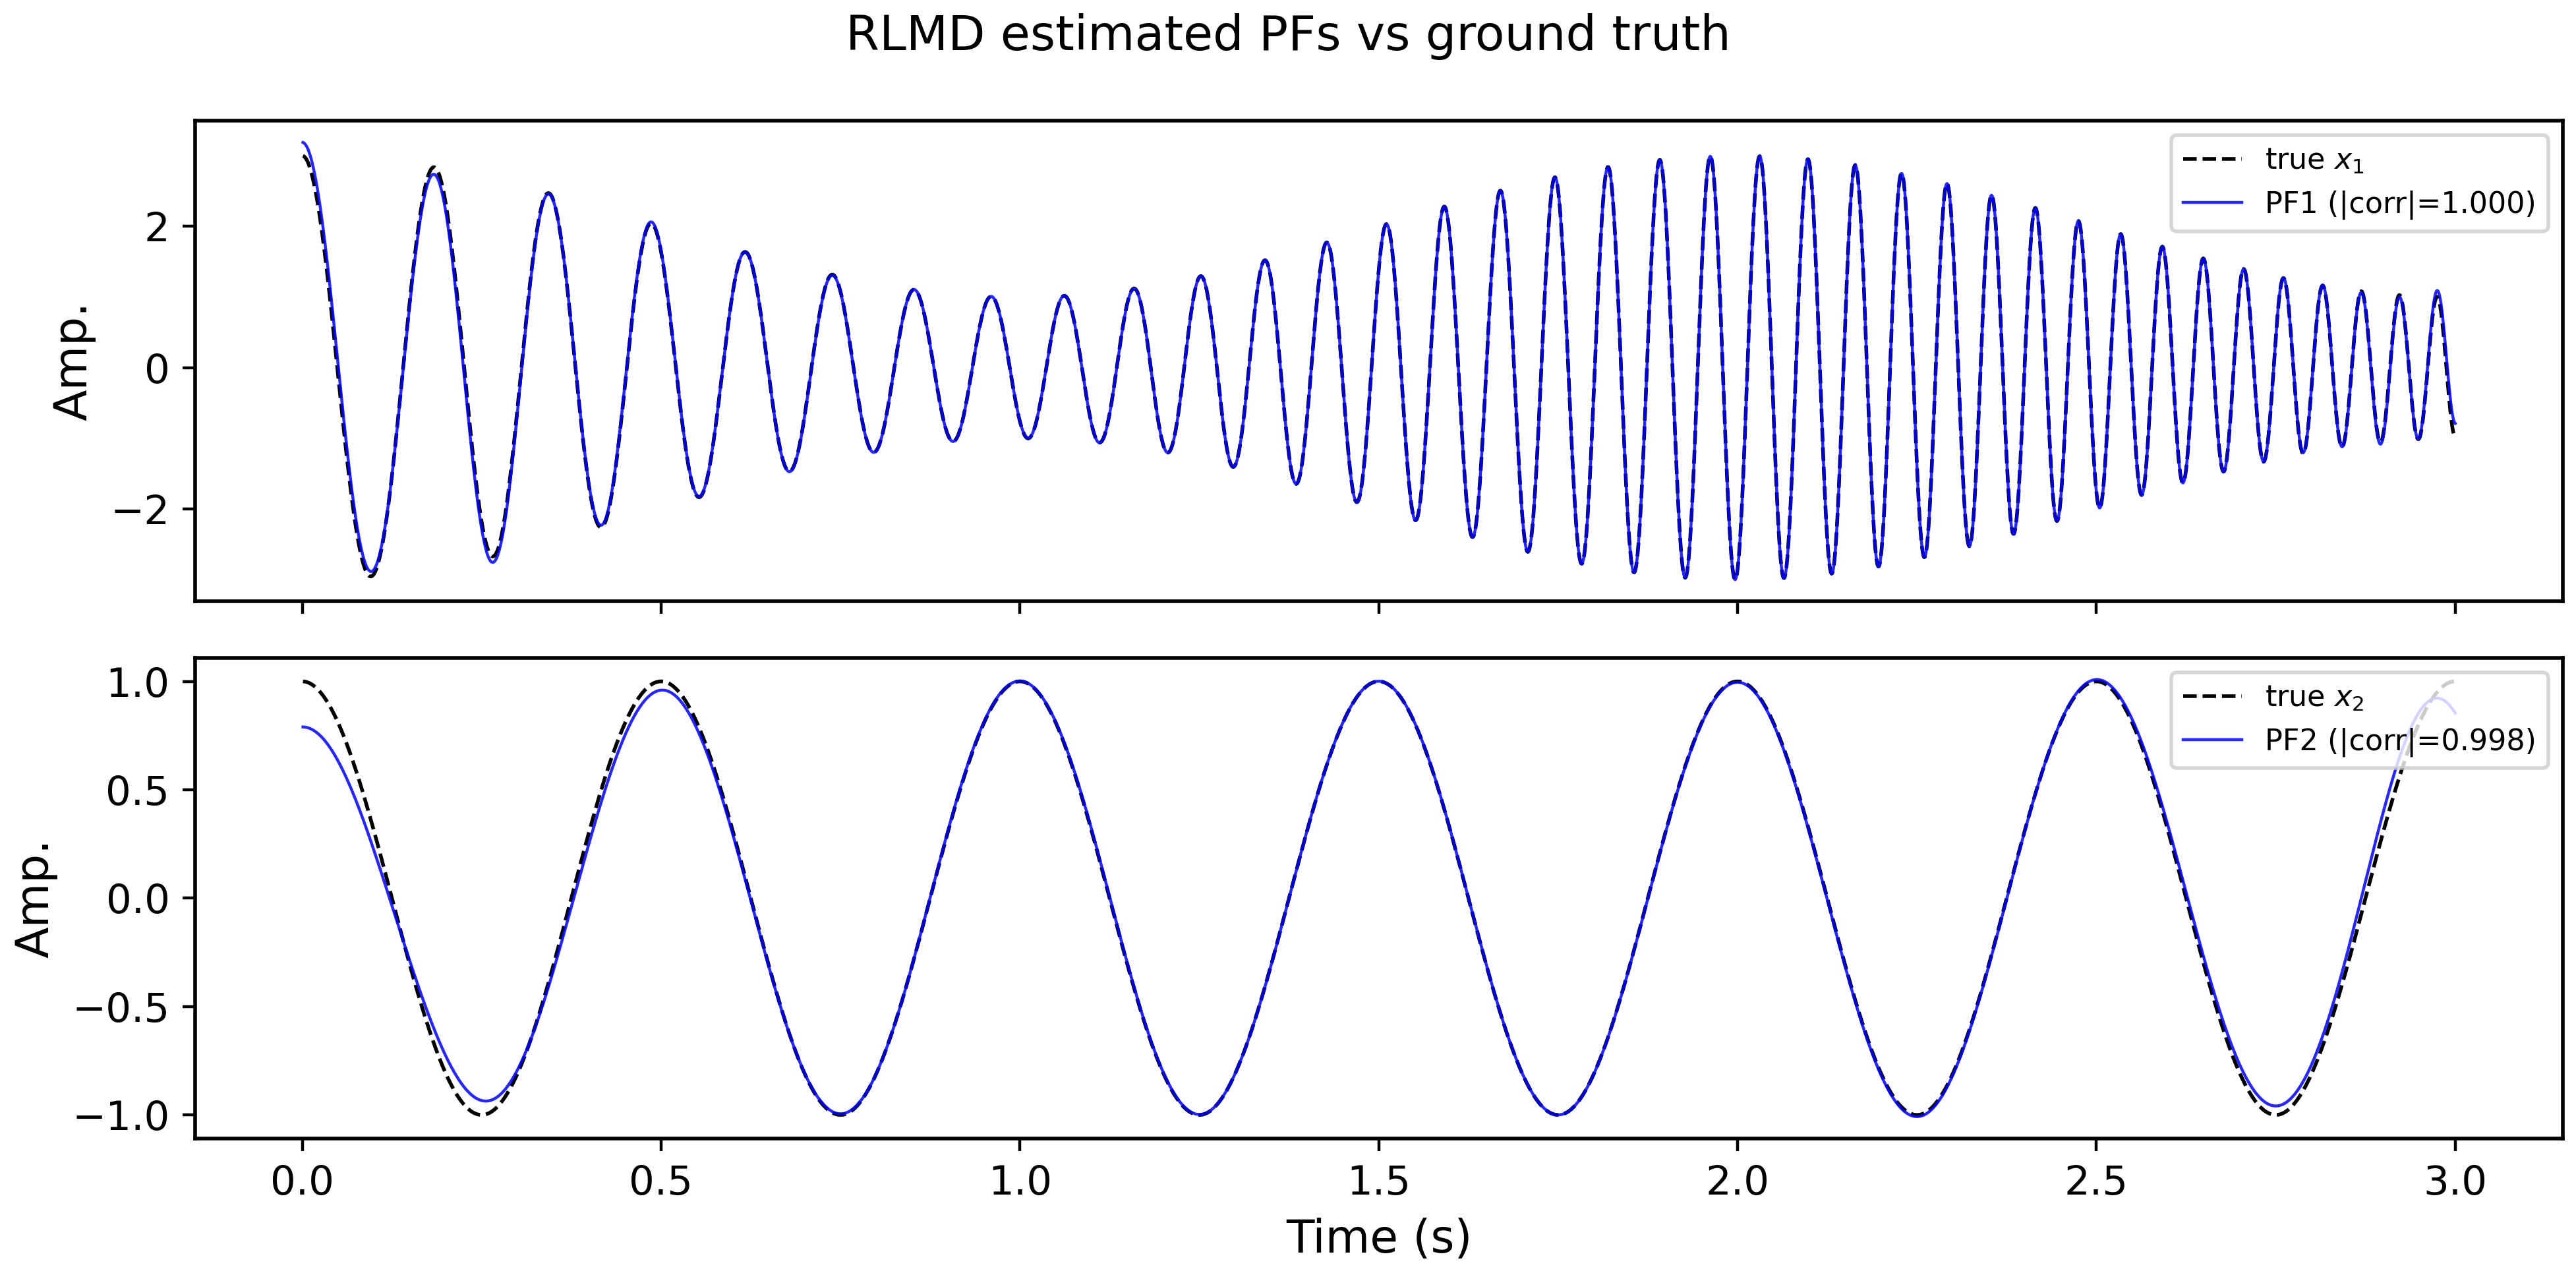

In [5]:
def best_match(true, pfs):
    corrs = [
        abs(float(np.corrcoef(true, pfs[k])[0, 1])) for k in range(pfs.shape[0] - 1)
    ]
    k = int(np.argmax(corrs))
    # flip sign if needed
    est = pfs[k]
    if float(np.corrcoef(true, est)[0, 1]) < 0:
        est = -est
    return k, est, corrs[k]


fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
for ax, true, name in zip(axes, [x1, x2], ["$x_1$", "$x_2$"]):
    k, est, c = best_match(true, pfs)
    ax.plot(t, true, "k--", lw=1.0, label=f"true {name}")
    ax.plot(t, est, "b", lw=0.8, alpha=0.85, label=f"PF{k+1} (|corr|={c:.3f})")
    ax.legend(loc="upper right", fontsize=8)
    ax.set_ylabel("Amp.")
axes[-1].set_xlabel("Time (s)")
fig.suptitle("RLMD estimated PFs vs ground truth")
fig.tight_layout()
plt.show()

### 3.3 Instantaneous amplitude / FM carriers

For each PF: $\mathrm{PF}_i = a_i\cdot s_i$ (AM × pure FM).


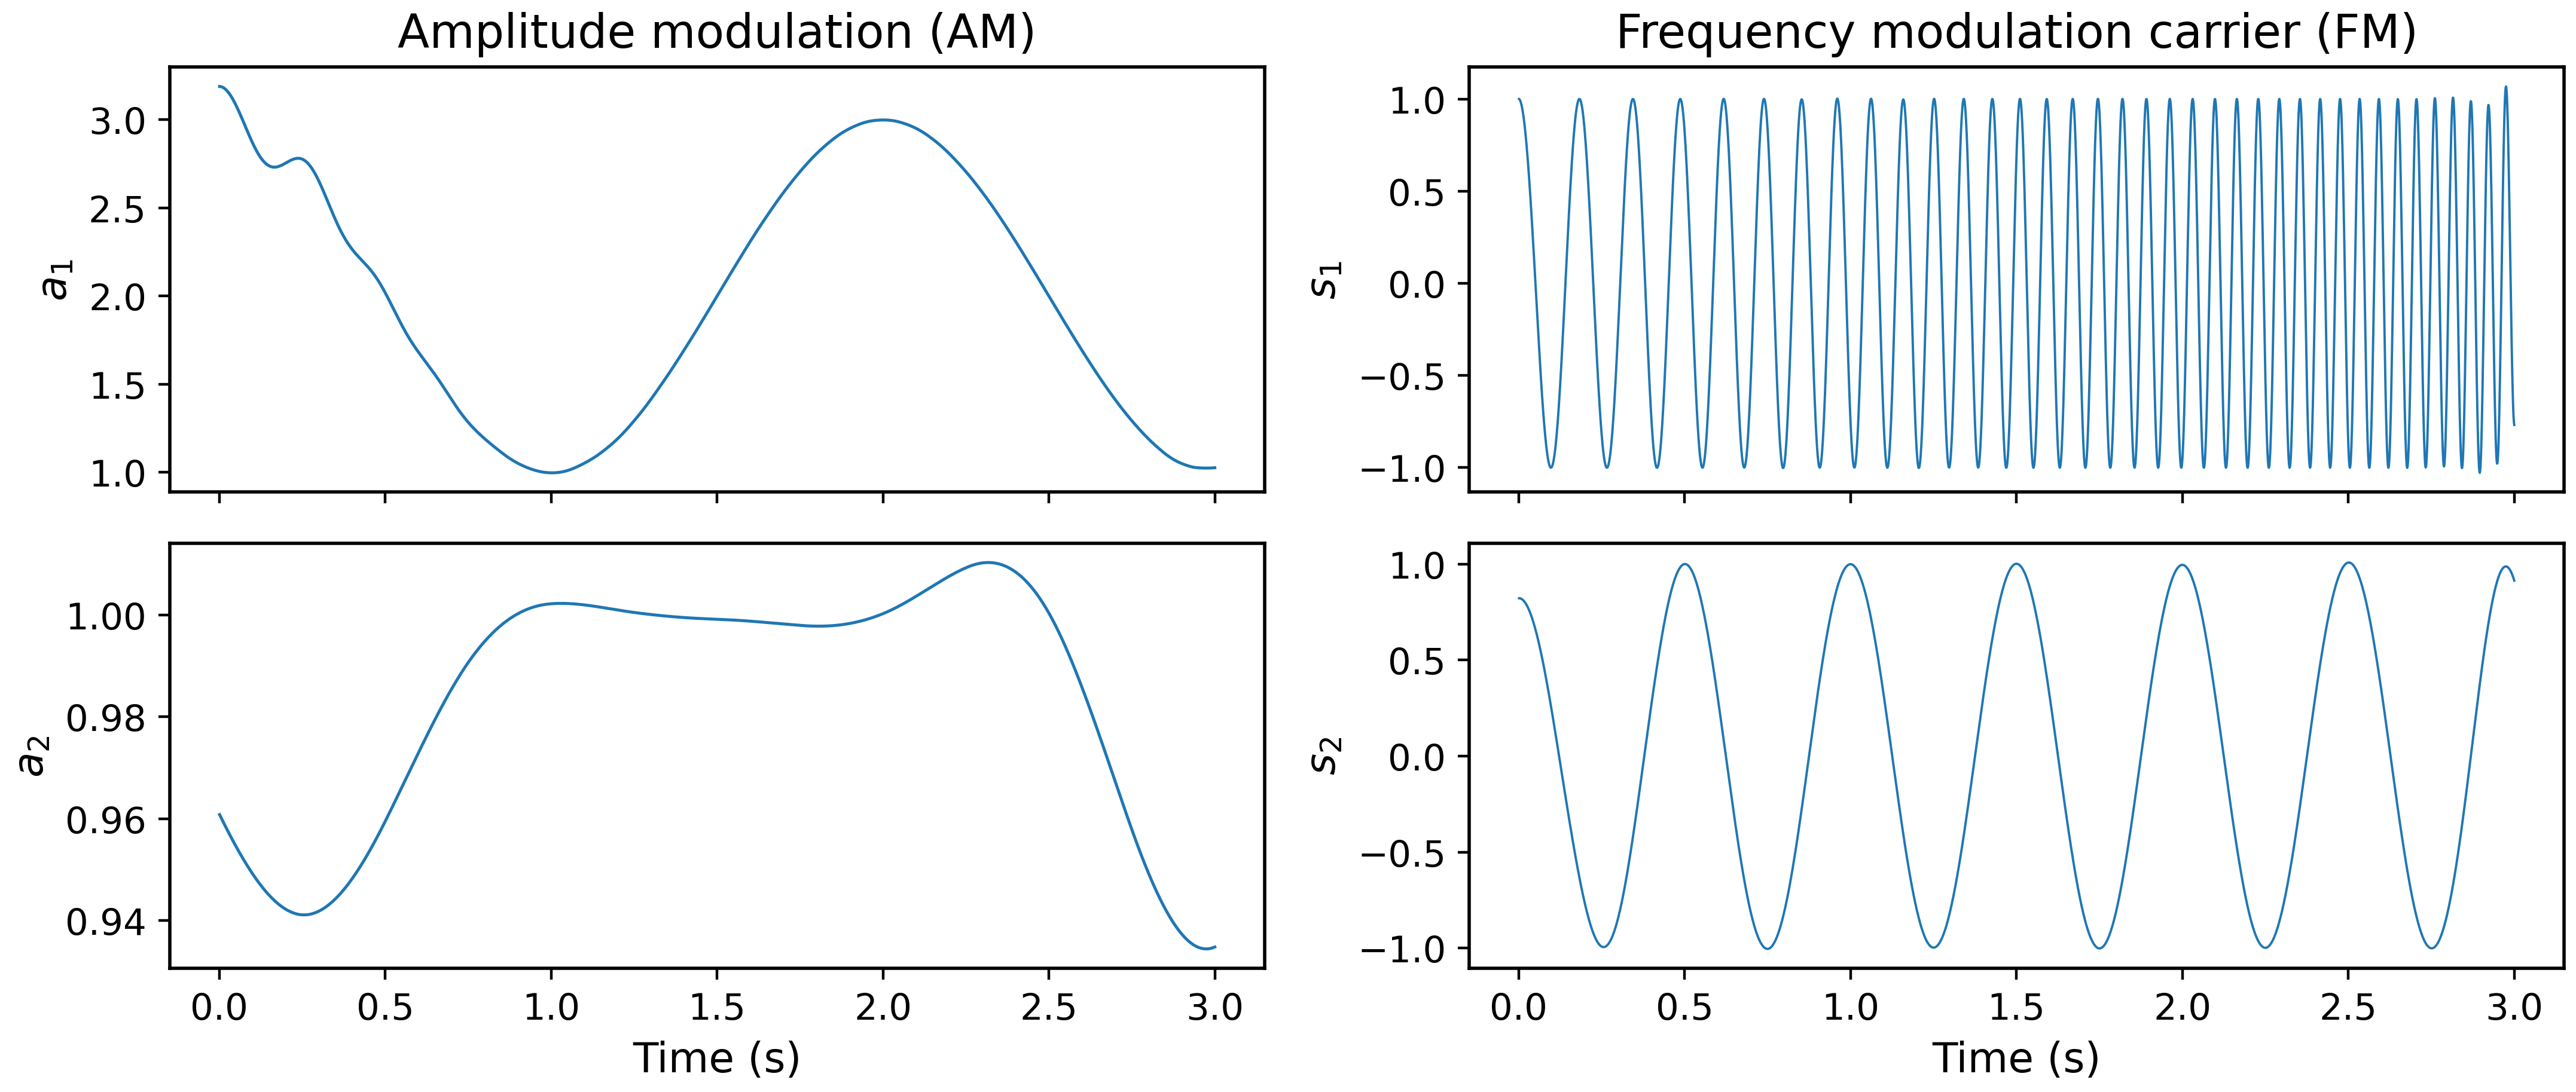

In [6]:
n_pf = ams.shape[0]
fig, axes = plt.subplots(n_pf, 2, figsize=(11, 2.4 * n_pf), sharex=True)
if n_pf == 1:
    axes = np.asarray([axes])
for i in range(n_pf):
    axes[i, 0].plot(t, ams[i], lw=0.9)
    axes[i, 0].set_ylabel(f"$a_{{{i+1}}}$")
    axes[i, 1].plot(t, fms[i], lw=0.7)
    axes[i, 1].set_ylabel(f"$s_{{{i+1}}}$")
axes[0, 0].set_title("Amplitude modulation (AM)")
axes[0, 1].set_title("Frequency modulation carrier (FM)")
axes[-1, 0].set_xlabel("Time (s)")
axes[-1, 1].set_xlabel("Time (s)")
fig.tight_layout()
plt.show()

## 4. Parameter cheat-sheet (MATLAB ↔ PySDKit)

| MATLAB (`lmd_public`) | `RLMD` | Default |
|---|---|---|
| `max_pfs` | `max_imfs` | 10 |
| `max_iter` | `max_iter` | 30 |
| `smooth_mode` | `smooth_mode` | `'ma'` |
| `ma_span` | `ma_span` | `'liu'` |
| `ma_iter_mode` | `ma_iter_mode` | `'fixed'` |
| `extd_r` | `extd_r` | 0.2 |
| `sifting_stopping_mode` | `sifting_stopping_mode` | `'liu'` |
| `stop_thre` | `stop_threshold` | `(0.005, 0.7, 0.05)` |

```python
from pysdkit import RLMD
pfs = RLMD(max_imfs=10, max_iter=30)(x)
pfs, ams, fms = RLMD()(x, return_all=True)
```
